In [47]:
%load_ext cuml.accel

The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel


In [48]:
# import sklearn
# sklearn.set_config(display="text")

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer , StandardScaler , OneHotEncoder
from sklearn.model_selection import train_test_split , cross_val_score , cross_val_predict
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer , make_column_selector
from sklearn.metrics import f1_score , precision_score , recall_score , confusion_matrix , precision_recall_curve , roc_curve
from sklearn.metrics import ConfusionMatrixDisplay

In [50]:
df = pd.read_csv('/kaggle/input/datasets/muhammadshoaibjamali/star-classification/star_classification.csv')
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [51]:
df = df.rename(columns={'u':'ultravoilet_filter' , 'g':'green_filter' , 'r':'red-filter' , 'i':'near_infrared_shift' , 'z':'infrared_filter'}) 

In [52]:
df = df.drop(columns=['obj_ID' , 'run_ID' , 'rerun_ID' , 'field_ID' , 'spec_obj_ID' , 'fiber_ID'])

In [53]:
df_numeric = df.select_dtypes(include='number')

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   alpha                100000 non-null  float64
 1   delta                100000 non-null  float64
 2   ultravoilet_filter   100000 non-null  float64
 3   green_filter         100000 non-null  float64
 4   red-filter           100000 non-null  float64
 5   near_infrared_shift  100000 non-null  float64
 6   infrared_filter      100000 non-null  float64
 7   cam_col              100000 non-null  int64  
 8   class                100000 non-null  object 
 9   redshift             100000 non-null  float64
 10  plate                100000 non-null  int64  
 11  MJD                  100000 non-null  int64  
dtypes: float64(8), int64(3), object(1)
memory usage: 9.2+ MB


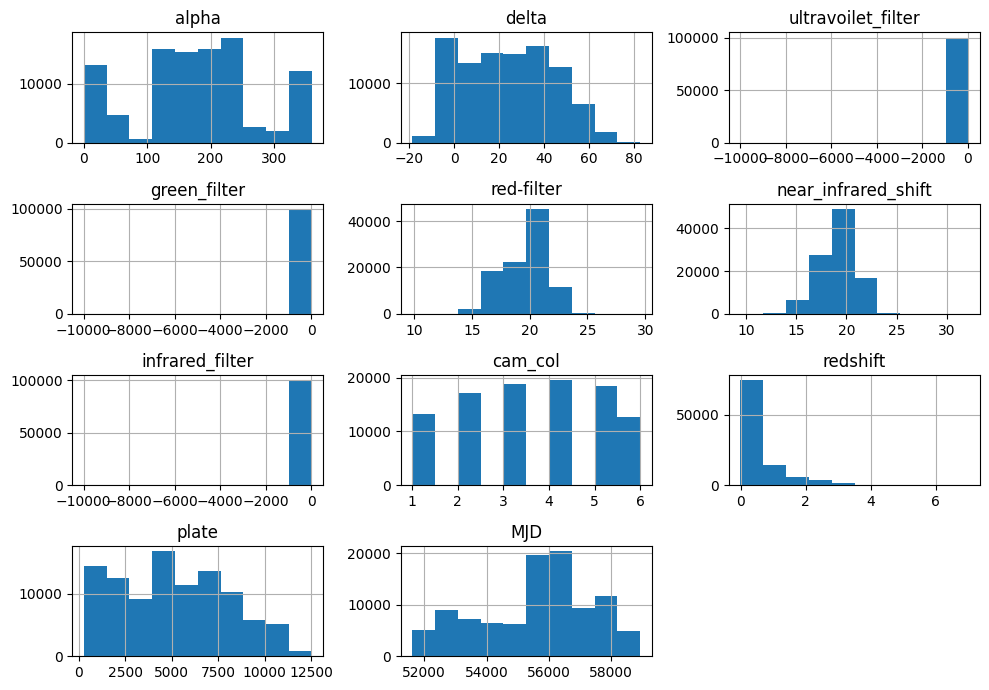

In [55]:
df.hist(figsize=(10,7))
plt.tight_layout()
plt.show()

(array([7.4405e+04, 1.3945e+04, 6.0120e+03, 3.8980e+03, 1.2000e+03,
        2.5700e+02, 6.3000e+01, 6.9000e+01, 5.7000e+01, 9.4000e+01]),
 array([-0.00997067,  0.6921509 ,  1.39427247,  2.09639403,  2.7985156 ,
         3.50063717,  4.20275873,  4.9048803 ,  5.60700187,  6.30912343,
         7.011245  ]),
 <BarContainer object of 10 artists>)

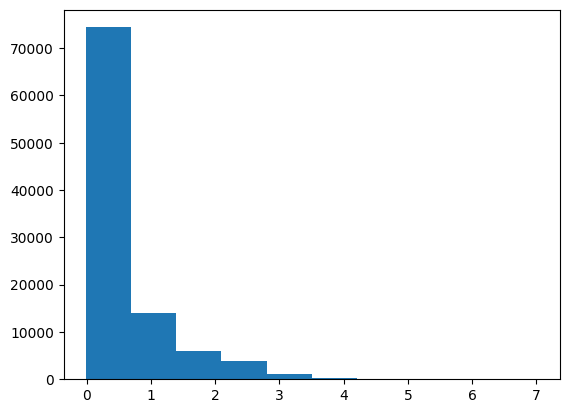

In [56]:
plt.hist(df['redshift'])

In [57]:
X = df.drop('class' , axis=1)
y = df['class']

In [58]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , stratify=y , random_state=42)

In [59]:
y_train_galaxy = (y_train == 'GALAXY')
y_test_galaxy = (y_test == 'GALAXY')

In [60]:
num_pipelines = make_pipeline(SimpleImputer(strategy='median') , StandardScaler())
cat_pipelines = make_pipeline(SimpleImputer(strategy='most_frequent') , OneHotEncoder() , StandardScaler())
log_transformer = FunctionTransformer(np.log1p , validate=True , feature_names_out='one-to-one')

In [61]:
preprocessor = ColumnTransformer([
    ('log_transformer' , log_transformer , ['redshift']),
    ('num' , num_pipelines , make_column_selector(dtype_include=np.number , pattern='^(?!redshift$).*')),
    ('cat' , cat_pipelines , make_column_selector(dtype_include=object))])

In [62]:
prepared_data = preprocessor.fit_transform(X_train)

In [63]:
df_prepared = pd.DataFrame(prepared_data , columns=preprocessor.get_feature_names_out() , index=X_train.index)

In [64]:
from sklearn.svm import SVC

In [65]:
svm_model = make_pipeline(preprocessor , SVC(random_state=42))
svm_model.fit(X_train , y_train_galaxy)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('log_transformer',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>,
                                                                      validate=True),
                                                  ['redshift']),
                                                 ('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7da373f81d00>),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7da373f67170>)])),
                ('svc', SVC(random_state=42))])

In [66]:
preprocessor.get_feature_names_out()

array(['log_transformer__redshift', 'num__alpha', 'num__delta',
       'num__ultravoilet_filter', 'num__green_filter', 'num__red-filter',
       'num__near_infrared_shift', 'num__infrared_filter', 'num__cam_col',
       'num__plate', 'num__MJD'], dtype=object)

(array([1.1000e+01, 8.4000e+01, 1.6300e+03, 1.4670e+04, 1.8028e+04,
        3.6131e+04, 9.2250e+03, 2.1000e+02, 8.0000e+00, 3.0000e+00]),
 array([-5.29277902, -4.22849764, -3.16421626, -2.09993487, -1.03565349,
         0.02862789,  1.09290927,  2.15719066,  3.22147204,  4.28575342,
         5.3500348 ]),
 <BarContainer object of 10 artists>)

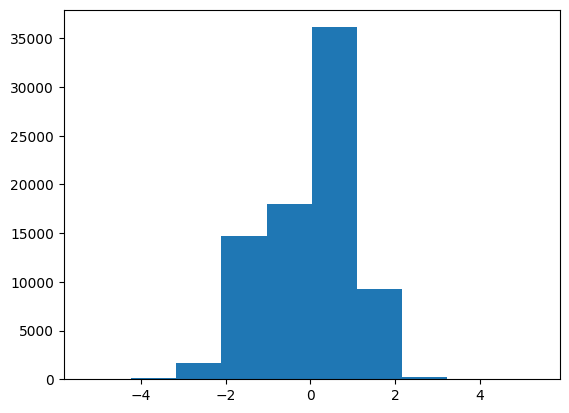

In [67]:
plt.hist(df_prepared['num__red-filter'])

In [68]:
y_train_pred = cross_val_score(svm_model , X_train , y_train_galaxy , cv=3 , scoring='accuracy')

In [69]:
y_train_pred

array([0.94506319, 0.92653842, 0.92518563])

In [70]:
from sklearn.dummy import DummyClassifier

In [71]:
dmy_model = make_pipeline(preprocessor , DummyClassifier())
dmy_model.fit(X_train , y_train_galaxy)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('log_transformer',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>,
                                                                      validate=True),
                                                  ['redshift']),
                                                 ('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7da373f81d00>),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7da373f67170>)])),
                ('dummyclassifier', DummyClassifier())])

In [72]:
y_dmy_pred = cross_val_score(dmy_model , X_train , y_train_galaxy , cv=3 , scoring='accuracy')

In [73]:
y_dmy_pred

array([0.59444257, 0.59444257, 0.59446486])

In [74]:
y_train_pred = cross_val_predict(svm_model , X_train , y_train_galaxy , cv=3 , method='decision_function')

In [75]:
precisions , recalls , thresholds = precision_recall_curve(y_train_galaxy , y_train_pred)

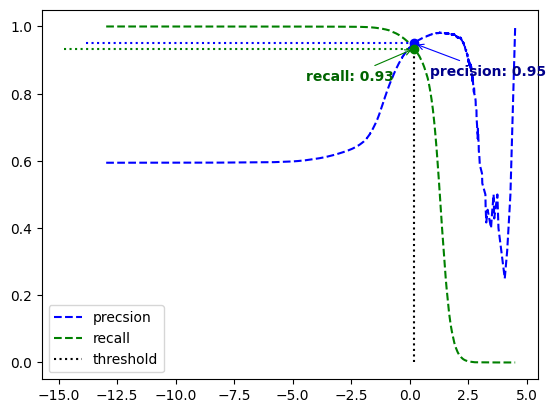

In [76]:
threshold = 0.2
plt.plot(thresholds , precisions[:-1] , 'b--' , label='precsion')
plt.plot(thresholds , recalls[:-1] ,'g--' , label='recall')
idx = np.argmin(np.abs(thresholds - threshold))
p = precisions[idx]
r = recalls[idx]
plt.vlines(threshold ,0 , p, 'k' , 'dotted' , label='threshold')
plt.hlines(precisions[idx], plt.xlim()[0], threshold, color='b', linestyle='dotted')
plt.hlines(recalls[idx], plt.xlim()[0], threshold, color='g', linestyle='dotted')
plt.plot(threshold , p , 'bo')
plt.plot(threshold , r , 'go')
plt.annotate(
    f'recall: {r:.2f}',
    xy = (threshold , r),
    xytext=(-15, -15),          # Shift text 15 points left, 15 points down
    textcoords="offset points",
    ha="right",
    va="top",
    color="darkgreen",
    weight="bold",
    arrowprops=dict(arrowstyle="->", color="green", lw=0.8)
)
plt.annotate(
    f"precision: {p:.2f}",
    xy=(threshold , p),
    xytext = (95 , -15),
    textcoords='offset points',
    ha='right',
    va='top',
    color='darkblue',
    weight='bold',
    arrowprops=dict(arrowstyle='->' , color='blue' , lw=0.8))
plt.legend()
plt.show()

In [77]:
optimal_threshold = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in optimal_threshold:
    y_scores = y_train_pred >= i
    scores = f1_score(y_train_galaxy , y_scores)
    print(f'threshold: {i} , score: {scores}')

threshold: 0.1 , score: 0.9426857503683435
threshold: 0.2 , score: 0.9417176288539603
threshold: 0.3 , score: 0.9397598085306437
threshold: 0.4 , score: 0.9361518736397526
threshold: 0.5 , score: 0.9306433193757138
threshold: 0.6 , score: 0.9237073985365533
threshold: 0.7 , score: 0.9137346073840061
threshold: 0.8 , score: 0.900643849542528
threshold: 0.9 , score: 0.8792754912266516


In [78]:
from sklearn.base import BaseEstimator, ClassifierMixin

class ThresholdedSVC(BaseEstimator, ClassifierMixin):
    def __init__(self, trained_model, threshold=0.0):
        self.trained_model = trained_model
        self.threshold = threshold
        self.classes_ = trained_model.classes_
        
    def fit(self, X, y):
        # The base model is already trained, so fitting just returns self
        return self
        
    def predict(self, X):
        # Get raw decision function scores
        scores = self.trained_model.decision_function(X)
        # Apply custom threshold boundary
        return (scores >= self.threshold).astype(int)
    
    def decision_function(self, X):
        return self.trained_model.decision_function(X)

In [79]:
# 1. Wrap your trained SVM with your custom threshold
final_model = ThresholdedSVC(trained_model=svm_model, threshold=0.2)

# 2. Now you can use it just like a regular scikit-learn model!
y_test_pred = final_model.predict(X_test)

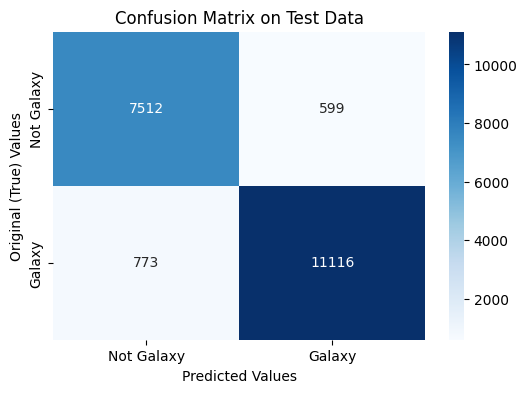

In [80]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compute the raw matrix
cm = confusion_matrix(y_test_galaxy, y_test_pred)

# 2. Plot it beautifully using Seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Galaxy', 'Galaxy'], 
            yticklabels=['Not Galaxy', 'Galaxy'])

plt.xlabel('Predicted Values')
plt.ylabel('Original (True) Values')
plt.title('Confusion Matrix on Test Data')
plt.show()

In [81]:
shapes = [X_train , X_test , y_train , y_test]
for i in shapes:
    print(f'{i.shape}')

(80000, 11)
(20000, 11)
(80000,)
(20000,)


In [82]:
svm_multilabel_model = make_pipeline(preprocessor , SVC(random_state=42))
svm_multilabel_model.fit(X_train , y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('log_transformer',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>,
                                                                      validate=True),
                                                  ['redshift']),
                                                 ('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7da373f81d00>),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7da373f67170>)])),
                ('svc', SVC(random_state=42))])

In [83]:
svm_multilabel_model.classes_

array(['GALAXY', 'QSO', 'STAR'], dtype=object)

In [84]:
svm_multilabel_model.decision_function(X_train.iloc[[2]])

array([[ 2.2975483 ,  1.13325914, -0.29993632]])

In [ ]:
y_pred_multilabels = cross_val_predict(svm_multilabel_model , X_train , y_train , cv=3)


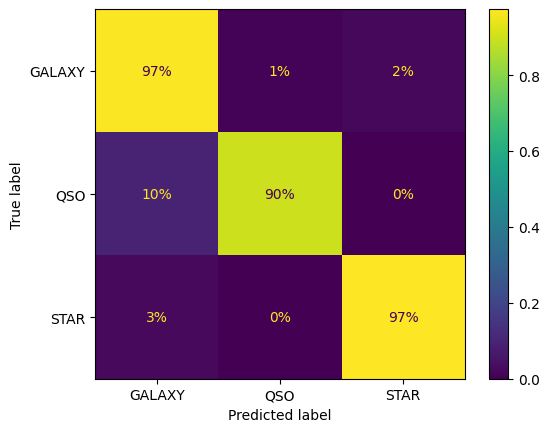

In [86]:
y_pred_test = svm_multilabel_model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, normalize='true', values_format='.0%')
plt.show()

In [87]:
from sklearn.ensemble import RandomForestClassifier

In [88]:
forest_model = make_pipeline(preprocessor , RandomForestClassifier(n_estimators=150 , random_state=42))
forest_model.fit(X_train , y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('log_transformer',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>,
                                                                      validate=True),
                                                  ['redshift']),
                                                 ('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_s...or object at 0x7da373f81d00>),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7da373f67170>)])),
                ('randomforestclassifier',
                 RandomForestClassifier(n_estimators=150, random_state=42))])

In [89]:
y_forest_pred = forest_model.predict(X_test)

In [90]:
y_scores = forest_model.predict_proba(X_test)[: , 1]

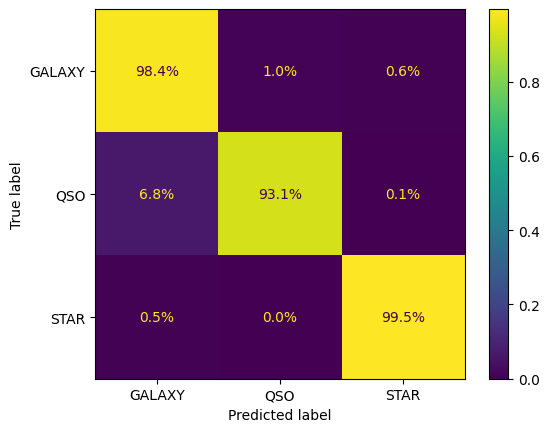

In [91]:
ConfusionMatrixDisplay.from_predictions(y_test , y_forest_pred , normalize='true' , values_format='.1%')
plt.show()

In [92]:
from sklearn.metrics import classification_report

print('SVM Multiclass Performance on Test Set')
print(classification_report(y_test, svm_multilabel_model.predict(X_test)))

print('Random Forest Performance on Test Set')
print(classification_report(y_test, y_forest_pred))

SVM Multiclass Performance on Test Set
              precision    recall  f1-score   support

      GALAXY       0.96      0.97      0.97     11889
         QSO       0.97      0.90      0.94      3792
        STAR       0.94      0.97      0.96      4319

    accuracy                           0.96     20000
   macro avg       0.96      0.95      0.95     20000
weighted avg       0.96      0.96      0.96     20000

Random Forest Performance on Test Set
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       0.98      1.00      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000

